  CLASSIFICATION METRICS DASHBOARD
Class 0 (Normal): 4727 (94.5%)
Class 1 (Fraud) : 273 (5.5%)
⚠️  Highly Imbalanced — Accuracy alone is misleading!

  MANUAL METRICS FROM CONFUSION MATRIX (NumPy)

Confusion Matrix:
[[776 169]
 [ 14  41]]

TP=41  FP=169  FN=14  TN=776

📐 MANUAL RESULTS:
  Accuracy    = (TP+TN)/(Total)  = 0.8170
  Precision   = TP/(TP+FP)       = 0.1952
  Recall      = TP/(TP+FN)       = 0.7455
  F1-Score    = 2PR/(P+R)        = 0.3094
  Specificity = TN/(TN+FP)       = 0.8212
  FPR         = FP/(FP+TN)       = 0.1788

✅ SKLEARN VERIFICATION:
  Accuracy  : 0.8170  | Manual: 0.8170
  Precision : 0.1952  | Manual: 0.1952
  Recall    : 0.7455  | Manual: 0.7455
  F1-Score  : 0.3094  | Manual: 0.3094
  AUC-ROC   : 0.8686
  Log-Loss  : 0.4406
  Kappa     : 0.2435

📋 FULL classification_report():

              precision    recall  f1-score   support

      Normal       0.98      0.82      0.89       945
       Fraud       0.20      0.75      0.31        55

    accuracy      

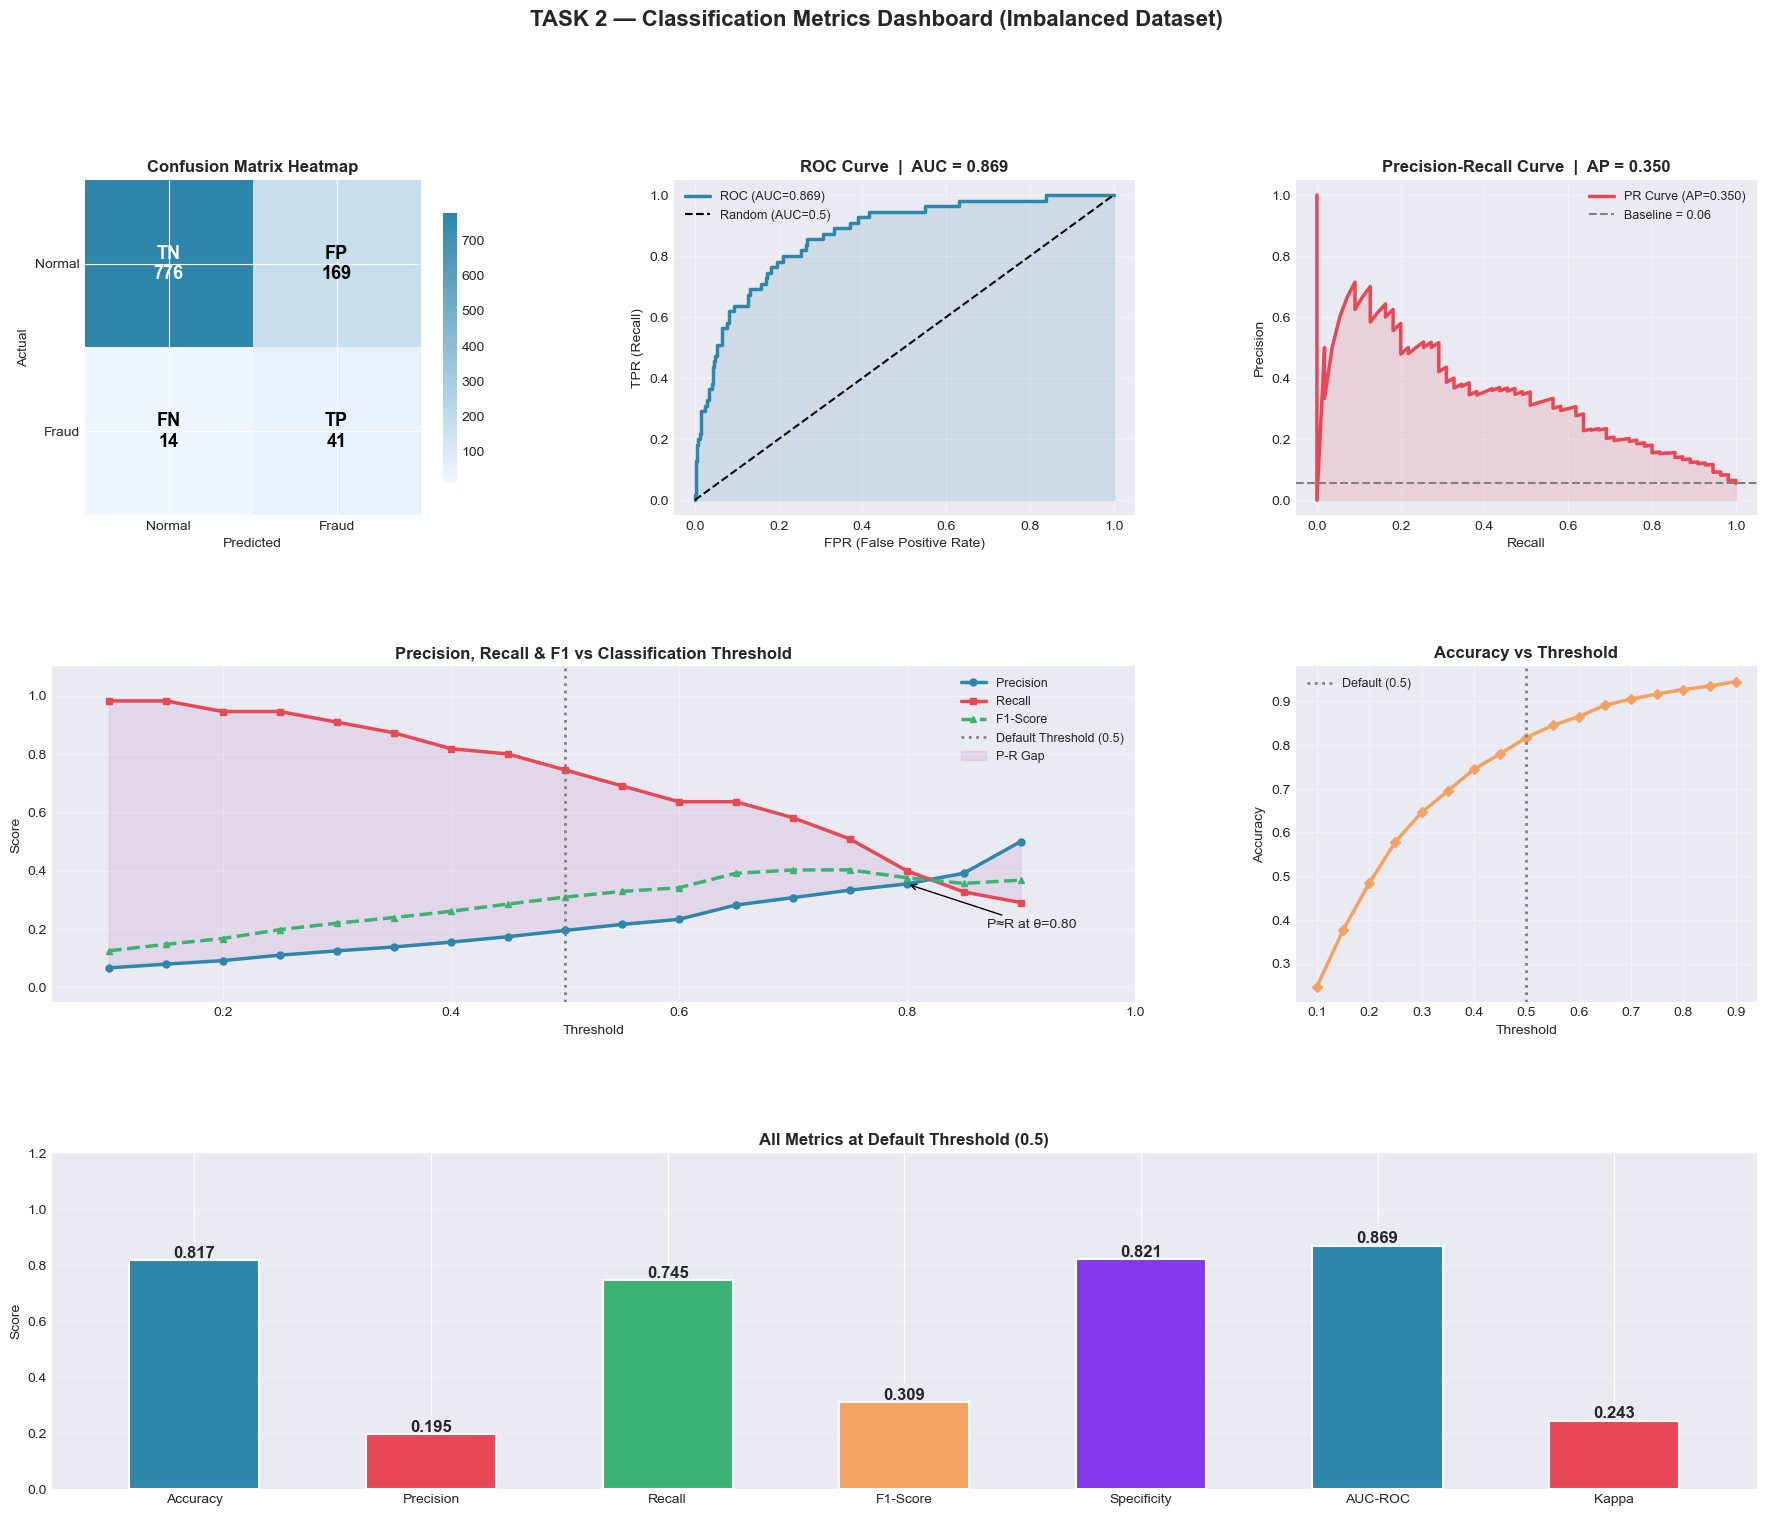


✅ TASK 2 COMPLETE — Metrics Dashboard!


In [1]:
# ============================================================
# TASK 2: CLASSIFICATION METRICS DASHBOARD
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, f1_score, precision_score,
    recall_score, log_loss, cohen_kappa_score
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
COLORS = ['#2E86AB', '#E84855', '#3BB273', '#F4A261', '#8338EC']

# ============================================================
# IMBALANCED DATASET — 95% Normal, 5% Fraud
# ============================================================

print("=" * 65)
print("  CLASSIFICATION METRICS DASHBOARD")
print("=" * 65)

X, y = make_classification(
    n_samples=5000, n_features=20, n_informative=15,
    n_redundant=5, weights=[0.95, 0.05],
    random_state=42, flip_y=0.01
)
print(f"Class 0 (Normal): {np.sum(y==0)} ({np.mean(y==0)*100:.1f}%)")
print(f"Class 1 (Fraud) : {np.sum(y==1)} ({np.mean(y==1)*100:.1f}%)")
print("⚠️  Highly Imbalanced — Accuracy alone is misleading!\n")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(class_weight='balanced',
                            max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ============================================================
# MANUAL COMPUTATION FROM CONFUSION MATRIX
# ============================================================

print("=" * 65)
print("  MANUAL METRICS FROM CONFUSION MATRIX (NumPy)")
print("=" * 65)

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print(f"\nConfusion Matrix:\n{cm}")
print(f"\nTP={TP}  FP={FP}  FN={FN}  TN={TN}")

accuracy_m  = (TP + TN) / (TP + TN + FP + FN)
precision_m = TP / (TP + FP) if (TP+FP)>0 else 0
recall_m    = TP / (TP + FN) if (TP+FN)>0 else 0
f1_m        = 2*precision_m*recall_m/(precision_m+recall_m) if (precision_m+recall_m)>0 else 0
specificity = TN / (TN + FP)
fpr_m       = FP / (FP + TN)

print(f"\n📐 MANUAL RESULTS:")
print(f"  Accuracy    = (TP+TN)/(Total)  = {accuracy_m:.4f}")
print(f"  Precision   = TP/(TP+FP)       = {precision_m:.4f}")
print(f"  Recall      = TP/(TP+FN)       = {recall_m:.4f}")
print(f"  F1-Score    = 2PR/(P+R)        = {f1_m:.4f}")
print(f"  Specificity = TN/(TN+FP)       = {specificity:.4f}")
print(f"  FPR         = FP/(FP+TN)       = {fpr_m:.4f}")

print(f"\n✅ SKLEARN VERIFICATION:")
print(f"  Accuracy  : {accuracy_score(y_test,y_pred):.4f}  | Manual: {accuracy_m:.4f}")
print(f"  Precision : {precision_score(y_test,y_pred):.4f}  | Manual: {precision_m:.4f}")
print(f"  Recall    : {recall_score(y_test,y_pred):.4f}  | Manual: {recall_m:.4f}")
print(f"  F1-Score  : {f1_score(y_test,y_pred):.4f}  | Manual: {f1_m:.4f}")
print(f"  AUC-ROC   : {roc_auc_score(y_test,y_prob):.4f}")
print(f"  Log-Loss  : {log_loss(y_test,y_prob):.4f}")
print(f"  Kappa     : {cohen_kappa_score(y_test,y_pred):.4f}")

print(f"\n📋 FULL classification_report():\n")
print(classification_report(y_test, y_pred,
      target_names=['Normal','Fraud']))

# ============================================================
# THRESHOLD ANALYSIS
# ============================================================

thresholds = np.arange(0.1, 0.95, 0.05)
precs, recs, f1s, accs = [], [], [], []

for t in thresholds:
    yp = (y_prob >= t).astype(int)
    precs.append(precision_score(y_test, yp, zero_division=0))
    recs.append(recall_score(y_test, yp, zero_division=0))
    f1s.append(f1_score(y_test, yp, zero_division=0))
    accs.append(accuracy_score(y_test, yp))

auc_score = roc_auc_score(y_test, y_prob)
fpr_arr, tpr_arr, _ = roc_curve(y_test, y_prob)
prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

# ============================================================
# ALL PLOTS
# ============================================================

fig = plt.figure(figsize=(22, 17))
fig.suptitle('TASK 2 — Classification Metrics Dashboard (Imbalanced Dataset)',
             fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.35)

# Plot 1: Confusion Matrix Heatmap
ax1 = fig.add_subplot(gs[0, 0])
cmap = LinearSegmentedColormap.from_list('cb', ['#EFF6FF','#2E86AB'], N=256)
im = ax1.imshow(cm, cmap=cmap)
plt.colorbar(im, ax=ax1, shrink=0.8)
ax1.set_xticks([0,1]); ax1.set_xticklabels(['Normal','Fraud'])
ax1.set_yticks([0,1]); ax1.set_yticklabels(['Normal','Fraud'])
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix Heatmap', fontweight='bold')
for i in range(2):
    for j in range(2):
        lbl   = [['TN','FP'],['FN','TP']][i][j]
        color = 'white' if cm[i,j] > cm.max()*0.5 else 'black'
        ax1.text(j, i, f'{lbl}\n{cm[i,j]}',
                 ha='center', va='center',
                 color=color, fontsize=13, fontweight='bold')

# Plot 2: ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(fpr_arr, tpr_arr, color=COLORS[0], lw=2.5,
         label=f'ROC (AUC={auc_score:.3f})')
ax2.fill_between(fpr_arr, tpr_arr, alpha=0.15, color=COLORS[0])
ax2.plot([0,1],[0,1], 'k--', lw=1.5, label='Random (AUC=0.5)')
ax2.set_xlabel('FPR (False Positive Rate)')
ax2.set_ylabel('TPR (Recall)')
ax2.set_title(f'ROC Curve  |  AUC = {auc_score:.3f}', fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)

# Plot 3: Precision-Recall Curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(rec_arr, prec_arr, color=COLORS[1], lw=2.5,
         label=f'PR Curve (AP={ap_score:.3f})')
ax3.fill_between(rec_arr, prec_arr, alpha=0.15, color=COLORS[1])
ax3.axhline(np.mean(y_test), color='gray', linestyle='--', lw=1.5,
            label=f'Baseline = {np.mean(y_test):.2f}')
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.set_title(f'Precision-Recall Curve  |  AP = {ap_score:.3f}',
              fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.4)

# Plot 4: P, R, F1 vs Threshold
ax4 = fig.add_subplot(gs[1, :2])
ax4.plot(thresholds, precs, COLORS[0], lw=2.5, marker='o',
         markersize=5, label='Precision')
ax4.plot(thresholds, recs,  COLORS[1], lw=2.5, marker='s',
         markersize=5, label='Recall')
ax4.plot(thresholds, f1s,   COLORS[2], lw=2.5, marker='^',
         markersize=5, label='F1-Score', linestyle='--')
ax4.axvline(0.5, color='gray', linestyle=':', lw=2,
            label='Default Threshold (0.5)')
ax4.fill_between(thresholds, precs, recs,
                 alpha=0.08, color='purple', label='P-R Gap')
# Annotate crossover
diff  = np.abs(np.array(precs) - np.array(recs))
ci    = np.argmin(diff)
ax4.annotate(f'P≈R at θ={thresholds[ci]:.2f}',
             xy=(thresholds[ci], precs[ci]),
             xytext=(thresholds[ci]+0.07, precs[ci]-0.15),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10)
ax4.set_xlabel('Threshold'); ax4.set_ylabel('Score')
ax4.set_title('Precision, Recall & F1 vs Classification Threshold',
              fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.4)
ax4.set_xlim(0.05, 1.0); ax4.set_ylim(-0.05, 1.1)

# Plot 5: Accuracy vs Threshold
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(thresholds, accs, color=COLORS[3], lw=2.5,
         marker='D', markersize=5)
ax5.axvline(0.5, color='gray', linestyle=':', lw=2,
            label='Default (0.5)')
ax5.set_xlabel('Threshold'); ax5.set_ylabel('Accuracy')
ax5.set_title('Accuracy vs Threshold', fontweight='bold')
ax5.legend(fontsize=9); ax5.grid(True, alpha=0.4)

# Plot 6: Final Metrics Summary Bar
ax6 = fig.add_subplot(gs[2, :])
m_names = ['Accuracy','Precision','Recall','F1-Score',
           'Specificity','AUC-ROC','Kappa']
m_vals  = [accuracy_m, precision_m, recall_m, f1_m,
           specificity, auc_score,
           cohen_kappa_score(y_test, y_pred)]
bar_cols = [COLORS[i % len(COLORS)] for i in range(len(m_names))]
bars = ax6.bar(m_names, m_vals, color=bar_cols,
               edgecolor='white', lw=1.5, width=0.55)
for bar, val in zip(bars, m_vals):
    ax6.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.01,
             f'{val:.3f}', ha='center',
             fontweight='bold', fontsize=12)
ax6.set_ylim(0, 1.2)
ax6.set_title('All Metrics at Default Threshold (0.5)', fontweight='bold')
ax6.set_ylabel('Score'); ax6.grid(True, alpha=0.3, axis='y')

plt.show()
print("\n✅ TASK 2 COMPLETE — Metrics Dashboard!")